# <center> **Tiny Image Net Competition**
### <center> **By:** María José Bernal Vélez

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        break
    break

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## 1. Libraries

In [2]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.nn as nn
from tqdm import tqdm
from PIL import Image
import pandas as pd
import numpy as np
import torch
import time
import os

## 2. Download data

### 2.1. Train df

In [3]:
train_id = "16ADiN0-geWlmkhN04bymFy_N7OA0SPHy"
train_url = f'https://drive.google.com/uc?id={train_id}'
# Load the CSV file into a pandas DataFrame
train_df = pd.read_csv(train_url)
train_df.head()

,File,Encoded_Label
0,n02437312/images/n02437312_229.JPEG,53
1,n02437312/images/n02437312_394.JPEG,53
2,n02437312/images/n02437312_15.JPEG,53
3,n02437312/images/n02437312_62.JPEG,53
4,n02437312/images/n02437312_17.JPEG,53


### 2.2. Validation df

In [4]:
val_id = "1lGkKcAD6Kc7JhfYsa9naVIwwc-MKdXQI"
val_url = f'https://drive.google.com/uc?id={val_id}'
# Load the CSV file into a pandas DataFrame
val_df = pd.read_csv(val_url)
val_df.head()

,File,Encoded_Label
0,val_4526.JPEG,115
1,val_7545.JPEG,88
2,val_1726.JPEG,149
3,val_4997.JPEG,99
4,val_6429.JPEG,149


### 2.3. Test df

In [5]:
test_id = "1lOi6xnfVghuzj1fYlIBbLNWWZQvahygQ"
test_url = f'https://drive.google.com/uc?id={test_id}'
# Load the CSV file into a pandas DataFrame
test_df = pd.read_csv(test_url)
test_df.head()

,File
0,val_9240.JPEG
1,val_9308.JPEG
2,val_3262.JPEG
3,val_3528.JPEG
4,val_4147.JPEG


## 3. Data processing

In [6]:
class CSVImageDataset(Dataset):
    def __init__(self, df, images_dir, transform=None):
        self.df = df
        self.images_dir = images_dir
        self.transform = transform
        self.has_labels = "Encoded_Label" in self.df.columns

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.images_dir, row["File"])
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        if self.has_labels:
            return img, torch.tensor(row["Encoded_Label"], dtype=torch.long)
        return img

### 3.1. Transforms

The input images were preprocessed through a series of transformations to standardize their size and improve model generalization. All images were resized to 128×128 pixels and cropped to 112×112 to ensure consistent input dimensions. During training, several data augmentation techniques were applied, including random cropping with padding, horizontal and vertical flips, rotations, color jittering, and occasional grayscale conversion. These augmentations increase data variability and help reduce overfitting.

For the custom CNN, images were normalized to the range [−1,1], while for the pretrained model, normalization followed the standard ImageNet statistics. Additionally, the pretrained pipeline included random erasing to further improve robustness. During evaluation, only deterministic transformations (resize, center crop, and normalization) were applied to ensure consistent and unbiased performance measurement.

In [7]:
# Transforms for the custom CNN (normalised to [-1, 1])
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomCrop(112, padding=14),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomRotation(15),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.CenterCrop(112),   # must match RandomCrop size used in training
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Transforms for the pretrained model (ImageNet normalisation statistics)
pretrained_train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomCrop(112, padding=14),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.2)),
])

pretrained_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.CenterCrop(112),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

### 3.2. Datasets

In [8]:
TRAIN_DIR = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train/"
VAL_DIR = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/val/images/"
TEST_DIR = VAL_DIR  # update if test images are stored in a different directory

train_dataset = CSVImageDataset(train_df, TRAIN_DIR, train_transform)
val_dataset = CSVImageDataset(val_df, VAL_DIR, test_transform)
test_dataset = CSVImageDataset(test_df, TEST_DIR, test_transform)

### 3.3. Data loaders

In [9]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

### 3.4. Sanity check

In [10]:
images, labels = next(iter(train_loader))
print(f"Batch shape : {images.shape}")   # [64, 3, 112, 112]
print(f"Labels shape: {labels.shape}")   # [64]
print(f"Unique labels in batch: {labels.unique()}")

Batch shape : torch.Size([64, 3, 112, 112])
Labels shape: torch.Size([64])
Unique labels in batch: tensor([  0,   3,   4,   8,   9,  10,  13,  14,  17,  23,  24,  30,  34,  39,
         45,  51,  52,  56,  60,  71,  79,  81,  82,  88,  91,  93,  94,  98,
        100, 103, 105, 108, 112, 117, 120, 125, 127, 139, 144, 145, 156, 160,
        163, 164, 166, 173, 174, 180, 192, 194, 195, 197])


### 3.5. Plotting data

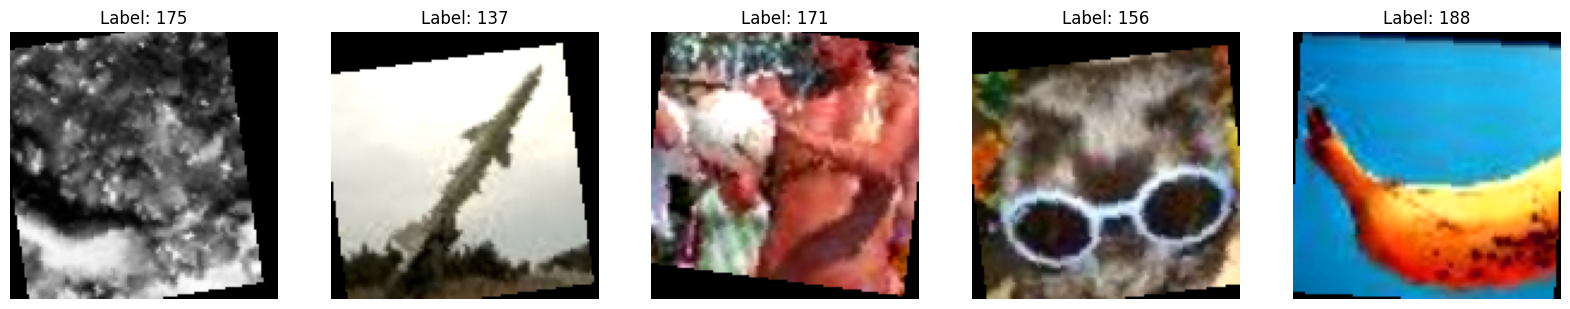

In [11]:
# Plotting the first few images in the training batch
images, labels = next(iter(train_loader))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: {int(labels[i])}")
plt.show()

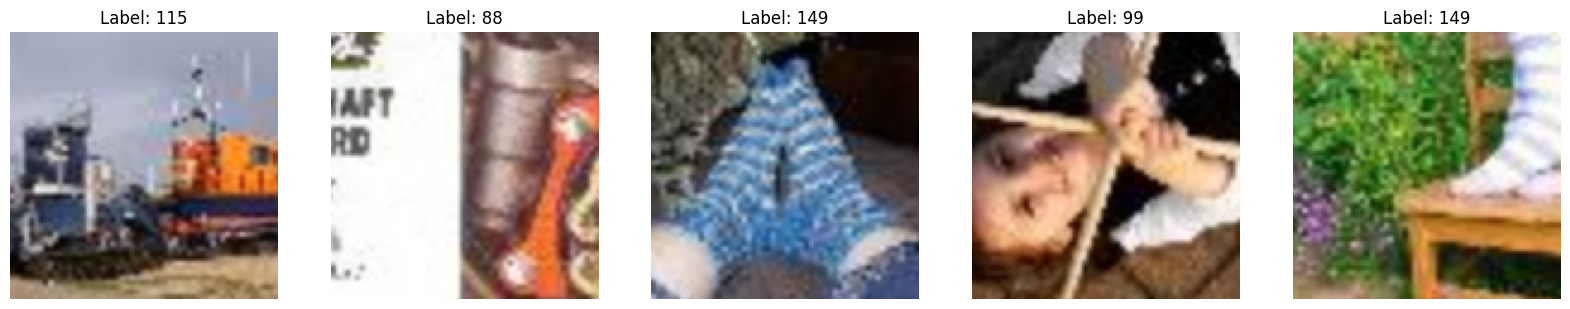

In [12]:
# Plotting the first few images in the validation batch
images, labels = next(iter(val_loader))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: {int(labels[i])}")
plt.show()

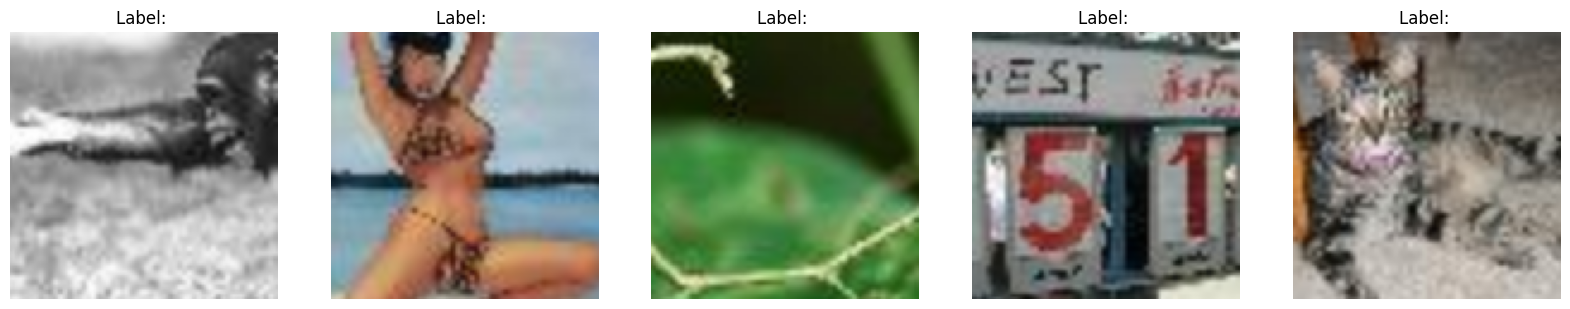

In [13]:
# Plotting the first few images in the test batch (no labels)
images = next(iter(test_loader))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title("Label: ")
plt.show()

## 4. Model Architecture

For this workshop, two models are going to be trained and compared. These are:
- Custom CNN built from scratch
- Transfer learning model using a pretrained EfficientNet-B0 backbone

In [14]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


### 4.1. Custom CNN
Firstly, a five-block convolutional neural network built from scratch will be tested with the following characteristics:

- Each block applies two 3×3 convolutions with batch normalisation and ReLU, followed by max-pooling to progressively halve the spatial dimensions.
- Global Average Pooling replaces a large flattened layer, reducing parameters and acting as a regulariser.
- Dropout is applied in the classifier head to prevent overfitting.

In [15]:
class ConvBlock(nn.Module):
    """Two conv layers with BN and ReLU, followed by max-pooling."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

    def forward(self, x):
        return self.block(x)


class TinyImageNetCNN(nn.Module):
    def __init__(self, num_classes=200, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 32),     # 112 -> 56
            ConvBlock(32, 64),    # 56  -> 28
            ConvBlock(64, 128),   # 28  -> 14
            ConvBlock(128, 256),  # 14  ->  7
            ConvBlock(256, 512),  # 7   ->  3
        )
        self.pool = nn.AdaptiveAvgPool2d(1)  # 3x3 -> 1x1
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.6),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = x.flatten(1)
        return self.classifier(x)


custom_cnn = TinyImageNetCNN(num_classes=200).to(device)
total_params = sum(p.numel() for p in custom_cnn.parameters() if p.requires_grad)
print(f"Custom CNN trainable parameters: {total_params:,}")
print(custom_cnn)

Custom CNN trainable parameters: 4,896,936
TinyImageNetCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=

### 4.2. Transfer Learning with EfficientNet-B0
Secondly, EfficientNet-B0 pretrained on ImageNet is used as the backbone, with the following distinctions:

- The original 1000-class head is replaced with a two-layer classifier for 200 classes.
- Training proceeds in two stages:
  1. Only the new head is trained with the backbone frozen
  2. The entire network is fine-tuned at a lower learning rate. 

In [16]:
def build_efficientnet(num_classes=200, freeze_backbone=True):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.2),
        nn.Linear(512, num_classes),
    )

    if freeze_backbone:
        for name, param in model.named_parameters():
            if "classifier" not in name:
                param.requires_grad = False

    return model


efficientnet = build_efficientnet(num_classes=200, freeze_backbone=True).to(device)
trainable = sum(p.numel() for p in efficientnet.parameters() if p.requires_grad)
total = sum(p.numel() for p in efficientnet.parameters())
print(f"EfficientNet-B0 — trainable: {trainable:,} / total: {total:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 117MB/s] 


EfficientNet-B0 — trainable: 758,472 / total: 4,766,020


## 5. Training Utilities

Now, in this section we're going to define reusable functions for evaluation, training, learning-rate scheduling, early stopping, and checkpointing.

### 5.1. Evaluation function
This function computes average cross-entropy loss, top-1 accuracy, and top-5 accuracy over a DataLoader.

In [17]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    top1_correct = 0
    top5_correct = 0
    total = 0

    with torch.inference_mode():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item() * images.size(0)
            total += labels.size(0)

            # Top-1 accuracy
            preds_top1 = logits.argmax(dim=1)
            top1_correct += (preds_top1 == labels).sum().item()

            # Top-5 accuracy
            top5_preds = logits.topk(5, dim=1).indices
            top5_correct += (top5_preds == labels.unsqueeze(1)).any(dim=1).sum().item()

    n = len(loader.dataset)
    return {
        "loss": total_loss / n,
        "top1_acc": top1_correct / total,
        "top5_acc": top5_correct / total,
    }

### 5.2. Training loop with early stopping and checkpointing

The `train_model` function trains for up to `num_epochs` epochs. If the validation top-1 accuracy does not improve for `patience` consecutive epochs, training stops early. The best weights are saved to `/kaggle/working/<name>.pt`. Additionally, `ReduceLROnPlateau` halves the learning rate when validation accuracy plateaus, and gradient clipping guards against unstable gradients during fine-tuning.

In [18]:
def train_model(
    model,
    train_loader,
    val_loader,
    lr=1e-3,
    weight_decay=1e-4,
    num_epochs=50,
    patience=10,
    name="model",
):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=5
    )

    checkpoint_path = f"/kaggle/working/{name}.pt"
    best_top1 = 0.0
    best_weights = None
    no_improve = 0

    history = {
        "train_loss": [], "val_loss": [],
        "val_top1": [], "val_top5": [],
    }

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        t0 = time.time()

        for images, labels in tqdm(train_loader, desc=f"[{name}] Epoch {epoch}/{num_epochs}", leave=False):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        val_metrics = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_top1"].append(val_metrics["top1_acc"])
        history["val_top5"].append(val_metrics["top5_acc"])

        scheduler.step(val_metrics["top1_acc"])

        if val_metrics["top1_acc"] > best_top1:
            best_top1 = val_metrics["top1_acc"]
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            torch.save(best_weights, checkpoint_path)
            no_improve = 0
        else:
            no_improve += 1

        elapsed = time.time() - t0
        print(
            f"Epoch {epoch:3d}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val Top-1: {val_metrics['top1_acc']:.4f} | "
            f"Val Top-5: {val_metrics['top5_acc']:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.2e} | "
            f"{elapsed:.1f}s"
        )

        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (best Val Top-1: {best_top1:.4f})")
            break

    if best_weights is not None:
        model.load_state_dict(best_weights)

    return model, history, best_top1

## 6. Experiments

### 6.1. Custom CNN from scratch

The custom CNN is trained for up to 60 epochs with early stopping (patience 12), and data loaders use the standard 0.5 normalisation transforms.

In [19]:
train_dataset_cnn = CSVImageDataset(train_df, TRAIN_DIR, train_transform)
val_dataset_cnn = CSVImageDataset(val_df, VAL_DIR, test_transform)

train_loader_cnn = DataLoader(train_dataset_cnn, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
val_loader_cnn = DataLoader(val_dataset_cnn, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

custom_cnn = TinyImageNetCNN(num_classes=200).to(device)

custom_cnn, history_cnn, best_top1_cnn = train_model(
    custom_cnn,
    train_loader_cnn,
    val_loader_cnn,
    lr=1e-3,
    weight_decay=1e-4,
    num_epochs=60,
    patience=12,
    name="custom_cnn",
)
print(f"\nCustom CNN best Val Top-1: {best_top1_cnn:.4f}")

Epoch   1/60 | Train Loss: 5.1285 | Val Loss: 4.8453 | Val Top-1: 0.0355 | Val Top-5: 0.1290 | LR: 1.00e-03 | 295.1s


Epoch   2/60 | Train Loss: 4.7569 | Val Loss: 4.3969 | Val Top-1: 0.0620 | Val Top-5: 0.2270 | LR: 1.00e-03 | 186.2s


Epoch   3/60 | Train Loss: 4.4814 | Val Loss: 4.1467 | Val Top-1: 0.0925 | Val Top-5: 0.2815 | LR: 1.00e-03 | 192.2s


Epoch   4/60 | Train Loss: 4.3111 | Val Loss: 3.9225 | Val Top-1: 0.1242 | Val Top-5: 0.3478 | LR: 1.00e-03 | 184.7s


Epoch   5/60 | Train Loss: 4.1710 | Val Loss: 3.8056 | Val Top-1: 0.1382 | Val Top-5: 0.3793 | LR: 1.00e-03 | 178.9s


...

Epoch  56/60 | Train Loss: 2.2493 | Val Loss: 2.0091 | Val Top-1: 0.5202 | Val Top-5: 0.7662 | LR: 1.00e-03 | 168.1s


Epoch  57/60 | Train Loss: 2.2401 | Val Loss: 2.0323 | Val Top-1: 0.5095 | Val Top-5: 0.7628 | LR: 1.00e-03 | 170.2s


Epoch  58/60 | Train Loss: 2.2186 | Val Loss: 2.0064 | Val Top-1: 0.5242 | Val Top-5: 0.7655 | LR: 1.00e-03 | 170.3s


Epoch  59/60 | Train Loss: 2.2058 | Val Loss: 2.0371 | Val Top-1: 0.5108 | Val Top-5: 0.7652 | LR: 1.00e-03 | 171.6s


Epoch  60/60 | Train Loss: 2.2066 | Val Loss: 2.0376 | Val Top-1: 0.5135 | Val Top-5: 0.7643 | LR: 1.00e-03 | 171.5s

Custom CNN best Val Top-1: 0.5242


### 6.2. EfficientNet-B0 — two-stage fine-tuning

**Stage 1:** trains only the new classification head for 5 epochs with the backbone frozen. This prevents the pretrained features from being disrupted by large gradients from the randomly-initialised head.

**Stage 2:** unfreezes all layers and fine-tunes end-to-end with a lower learning rate and stronger weight decay.

In [20]:
train_dataset_pt = CSVImageDataset(train_df, TRAIN_DIR, pretrained_train_transform)
val_dataset_pt = CSVImageDataset(val_df, VAL_DIR, pretrained_test_transform)

train_loader_pt = DataLoader(train_dataset_pt, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
val_loader_pt = DataLoader(val_dataset_pt, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

efficientnet = build_efficientnet(num_classes=200, freeze_backbone=True).to(device)

print("Stage 1: training head only (backbone frozen) ...")
efficientnet, history_pt_stage1, _ = train_model(
    efficientnet,
    train_loader_pt,
    val_loader_pt,
    lr=1e-3,
    weight_decay=1e-4,
    num_epochs=5,
    patience=5,
    name="efficientnet_stage1",
)

Stage 1: training head only (backbone frozen) ...


Epoch   1/5 | Train Loss: 3.7396 | Val Loss: 2.6864 | Val Top-1: 0.3935 | Val Top-5: 0.6613 | LR: 1.00e-03 | 159.0s


Epoch   2/5 | Train Loss: 3.3982 | Val Loss: 2.5787 | Val Top-1: 0.4045 | Val Top-5: 0.6797 | LR: 1.00e-03 | 163.4s


Epoch   3/5 | Train Loss: 3.3735 | Val Loss: 2.5794 | Val Top-1: 0.4112 | Val Top-5: 0.6767 | LR: 1.00e-03 | 157.4s


Epoch   4/5 | Train Loss: 3.3587 | Val Loss: 2.5710 | Val Top-1: 0.4123 | Val Top-5: 0.6717 | LR: 1.00e-03 | 156.9s


Epoch   5/5 | Train Loss: 3.3625 | Val Loss: 2.5682 | Val Top-1: 0.4145 | Val Top-5: 0.6768 | LR: 1.00e-03 | 160.5s


In [21]:
for param in efficientnet.parameters():
    param.requires_grad = True

trainable_stage2 = sum(p.numel() for p in efficientnet.parameters() if p.requires_grad)
print(f"Stage 2: fine-tuning all {trainable_stage2:,} parameters ...")

efficientnet, history_pt_stage2, best_top1_pt = train_model(
    efficientnet,
    train_loader_pt,
    val_loader_pt,
    lr=1e-4,
    weight_decay=5e-5,
    num_epochs=40,
    patience=10,
    name="efficientnet_finetuned",
)
print(f"\nEfficientNet best Val Top-1: {best_top1_pt:.4f}")

Stage 2: fine-tuning all 4,766,020 parameters ...


Epoch   1/40 | Train Loss: 2.3215 | Val Loss: 1.4455 | Val Top-1: 0.6393 | Val Top-5: 0.8543 | LR: 1.00e-04 | 176.2s


Epoch   2/40 | Train Loss: 1.8842 | Val Loss: 1.3111 | Val Top-1: 0.6737 | Val Top-5: 0.8772 | LR: 1.00e-04 | 175.2s


Epoch   3/40 | Train Loss: 1.6991 | Val Loss: 1.2339 | Val Top-1: 0.6960 | Val Top-5: 0.8852 | LR: 1.00e-04 | 173.2s


Epoch   4/40 | Train Loss: 1.5685 | Val Loss: 1.1871 | Val Top-1: 0.7027 | Val Top-5: 0.8913 | LR: 1.00e-04 | 176.9s


...

Epoch  36/40 | Train Loss: 0.5584 | Val Loss: 1.1990 | Val Top-1: 0.7400 | Val Top-5: 0.9048 | LR: 5.00e-05 | 171.8s


Epoch  37/40 | Train Loss: 0.5560 | Val Loss: 1.1899 | Val Top-1: 0.7408 | Val Top-5: 0.9050 | LR: 2.50e-05 | 168.6s


Epoch  38/40 | Train Loss: 0.5208 | Val Loss: 1.1901 | Val Top-1: 0.7438 | Val Top-5: 0.9063 | LR: 2.50e-05 | 168.2s


Epoch  39/40 | Train Loss: 0.5135 | Val Loss: 1.1871 | Val Top-1: 0.7458 | Val Top-5: 0.9052 | LR: 2.50e-05 | 170.1s


Epoch  40/40 | Train Loss: 0.5058 | Val Loss: 1.1998 | Val Top-1: 0.7433 | Val Top-5: 0.9050 | LR: 2.50e-05 | 174.1s

EfficientNet best Val Top-1: 0.7458


### 6.3. Results summary

In [22]:
results = pd.DataFrame([
    {
        "Model": "Custom CNN",
        "Best Val Top-1": f"{best_top1_cnn:.4f}",
        "Best Val Top-5": f"{max(history_cnn['val_top5']):.4f}",
        "Epochs trained": len(history_cnn["train_loss"]),
    },
    {
        "Model": "EfficientNet-B0",
        "Best Val Top-1": f"{best_top1_pt:.4f}",
        "Best Val Top-5": f"{max(history_pt_stage2['val_top5']):.4f}",
        "Epochs trained": len(history_pt_stage1["train_loss"]) + len(history_pt_stage2["train_loss"]),
    },
])
print(results.to_string(index=False))

          Model Best Val Top-1 Best Val Top-5  Epochs trained
     Custom CNN         0.5242         0.7662              60
EfficientNet-B0         0.7458         0.9063              45


From the results above, it is possible to see that EfficientNet-B0 clearly outperforms the custom CNN, with much higher Top-1 and Top-5 accuracy even after training for fewer epochs. This is mainly due to its pretrained features, which give it a strong advantage over the CNN trained from scratch.

## 7. Evaluation

### 7.1. Training curves

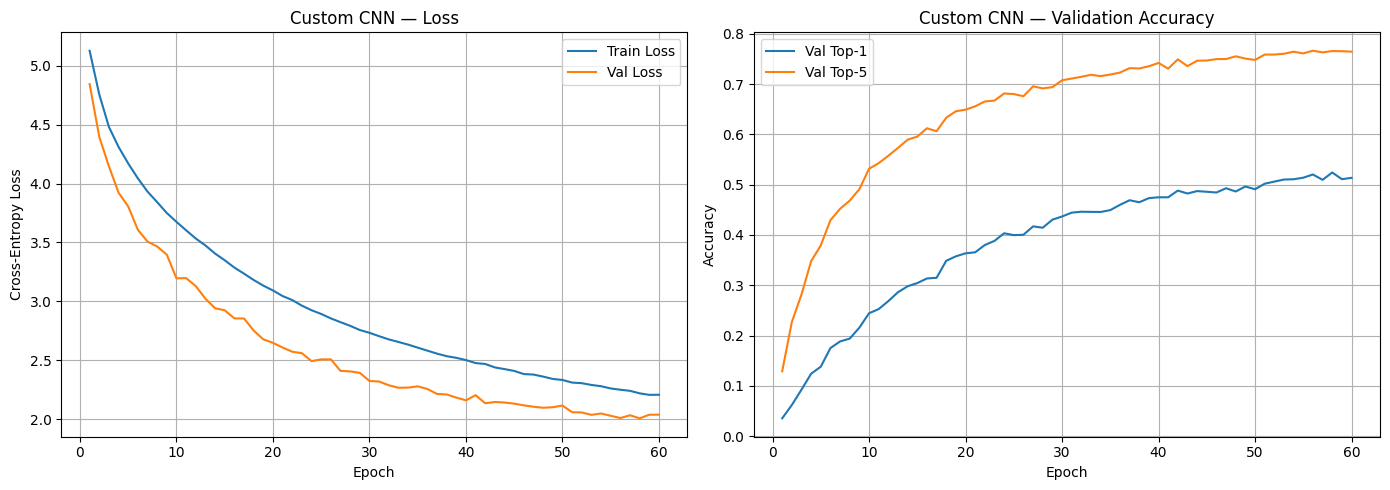

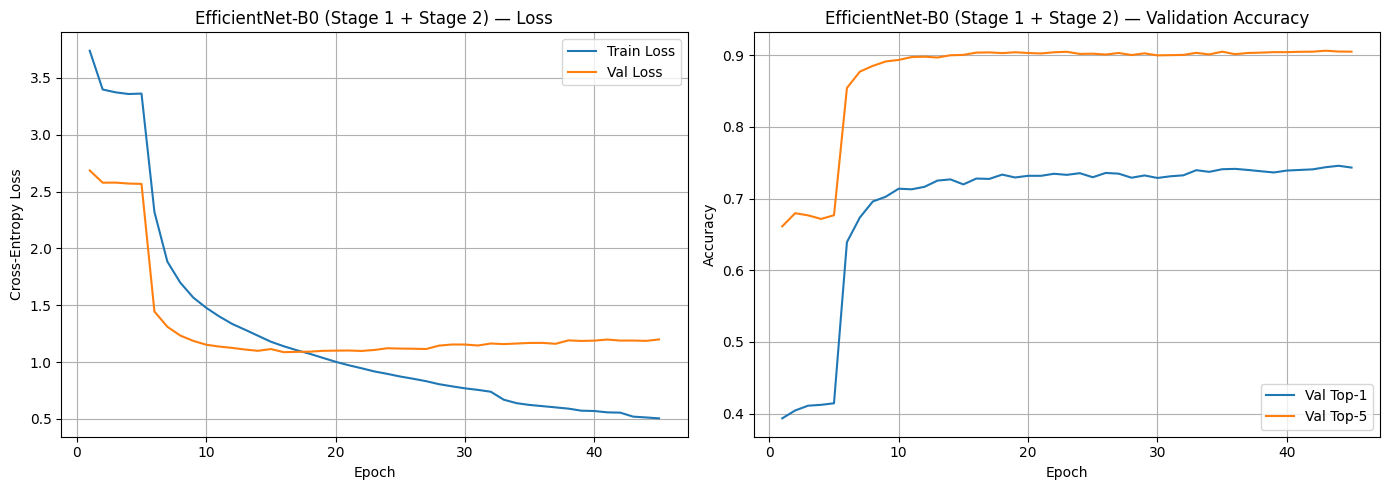

In [23]:
def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], label="Val Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].set_title(f"{title} — Loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs, history["val_top1"], label="Val Top-1")
    axes[1].plot(epochs, history["val_top5"], label="Val Top-5")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"{title} — Validation Accuracy")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


plot_history(history_cnn, "Custom CNN")

# Concatenate EfficientNet stage histories for a single continuous plot
history_pt_combined = {
    "train_loss": history_pt_stage1["train_loss"] + history_pt_stage2["train_loss"],
    "val_loss": history_pt_stage1["val_loss"] + history_pt_stage2["val_loss"],
    "val_top1": history_pt_stage1["val_top1"] + history_pt_stage2["val_top1"],
    "val_top5": history_pt_stage1["val_top5"] + history_pt_stage2["val_top5"],
}
plot_history(history_pt_combined, "EfficientNet-B0 (Stage 1 + Stage 2)")

From the graphs above it is possible to note that the **custom CNN** had a steady but slow learning, as both training and validation loss decrease smoothly, and accuracy improves gradually. Additionally, there is no strong overfitting, but performance plateaus at a relatively low level, indicating that it has a limited capacity to learn complex features.

In contrast, the graphs of **EfficientNet-B0** show that it learns much faster, with a sharp drop in loss and rapid jump in accuracy early on. However, after this point, validation loss slightly increases while training loss keeps decreasing, suggesting a small overfitting. Despite this, it stabilizes at a much higher accuracy than the CNN.

### 7.2. Final validation metrics

Best checkpoints are reloaded from disk and evaluated on the full validation
set to obtain the final reported numbers.

In [29]:
criterion = nn.CrossEntropyLoss()

custom_cnn.load_state_dict(torch.load("/kaggle/working/custom_cnn.pt", map_location=device))
metrics_cnn = evaluate(custom_cnn, val_loader_cnn, criterion)

efficientnet.load_state_dict(torch.load("/kaggle/working/efficientnet_finetuned.pt", map_location=device))
metrics_pt = evaluate(efficientnet, val_loader_pt, criterion)

print("=== Custom CNN ===")
print(f"  Val Loss  : {metrics_cnn['loss']:.4f}")
print(f"  Val Top-1 : {metrics_cnn['top1_acc']:.4f}")
print(f"  Val Top-5 : {metrics_cnn['top5_acc']:.4f}")

print("\n=== EfficientNet-B0 ===")
print(f"  Val Loss  : {metrics_pt['loss']:.4f}")
print(f"  Val Top-1 : {metrics_pt['top1_acc']:.4f}")
print(f"  Val Top-5 : {metrics_pt['top5_acc']:.4f}")

=== Custom CNN ===
  Val Loss  : 2.0064
  Val Top-1 : 0.5242
  Val Top-5 : 0.7655

=== EfficientNet-B0 ===
  Val Loss  : 1.1871
  Val Top-1 : 0.7458
  Val Top-5 : 0.9052


EfficientNet-B0 clearly outperforms the custom CNN, achieving lower validation loss (1.1871 vs. 2.0064) and significantly higher Top-1 (74.58% vs. 52.42%) and Top-5 accuracy (90.52% vs. 76.55%). This superior performance is likely due to its pretrained backbone, which provides richer feature representations and allows for better generalization compared to the CNN trained from scratch.

Given these results, EfficientNet-B0 will be used as the final model for the test set.

## 8. Submission

### 8.1. Select best model

The model with the higher validation top-1 accuracy is selected for submission. The corresponding test loader uses the matching normalisation.

In [25]:
if best_top1_pt >= best_top1_cnn:
    best_model = efficientnet
    best_test_loader = DataLoader(
        CSVImageDataset(test_df, TEST_DIR, pretrained_test_transform),
        batch_size=64,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
    )
    print(f"Using EfficientNet-B0 (Val Top-1: {best_top1_pt:.4f})")
else:
    best_model = custom_cnn
    best_test_loader = DataLoader(
        CSVImageDataset(test_df, TEST_DIR, test_transform),
        batch_size=64,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
    )
    print(f"Using Custom CNN (Val Top-1: {best_top1_cnn:.4f})")

Using EfficientNet-B0 (Val Top-1: 0.7458)


### 8.2. Generate submission CSV

In [26]:
best_model.eval()
filenames = test_df["File"].tolist()
predictions = []

with torch.inference_mode():
    for batch in tqdm(best_test_loader, desc="Generating predictions"):
        images = batch.to(device)
        logits = best_model(images)
        preds = logits.argmax(dim=1).cpu().tolist()
        predictions.extend(preds)

assert len(predictions) == len(filenames), (
    f"Length mismatch: {len(predictions)} predictions vs {len(filenames)} filenames"
)

submission = pd.DataFrame({"File": filenames, "Encoded_Label": predictions})
submission.to_csv("/kaggle/working/submission.csv", index=False)
print(f"Saved submission.csv — {len(submission)} rows")
submission.head()

Generating predictions: 100%|██████████| 63/63 [00:10<00:00,  5.90it/s]

Saved submission.csv — 4000 rows


,File,Encoded_Label
0,val_9240.JPEG,139
1,val_9308.JPEG,74
2,val_3262.JPEG,40
3,val_3528.JPEG,65
4,val_4147.JPEG,30
